In [2]:
import numpy as np


In [3]:
param = {}
num_mothers = 5
i_ANC = np.array([[1, 0, 1, 1, 0],
                 [1, 0, 1, 1, 0],
                 [1, 0, 1, 1, 0],
                 [1, 0, 1, 1, 0]]
                 )  # Some mothers received ANC, some didn’t
param['p_anemia_anc'] = np.array([0.2, 0.5])  # No ANC → 20% anemia, With ANC → 50%
selected_probs = param['p_anemia_anc'][i_ANC]
selected_probs
i_anemia = np.random.binomial(1, selected_probs)
i_anemia

array([[0, 0, 1, 1, 1],
       [1, 0, 0, 0, 0],
       [1, 1, 1, 0, 0],
       [1, 1, 0, 1, 0]])

In [4]:
i_highrisk = np.array([1, 0, 1, 1, 0])
i_highrisk.shape[0]

5

In [5]:
i_loc_new = np.array([1, 2, 3, 0])
severe_transfer_mask = np.array([0,0,1,0], dtype=bool)
severe_indices = i_loc_new[severe_transfer_mask]
severe_indices

array([3])

In [6]:
severe_transfer_mask = np.array([0,0,1,0], dtype=bool)
notsevere_transfer_mask =  np.array([1,1,0,1], dtype=bool)
index_need_transfer = np.where(severe_transfer_mask | notsevere_transfer_mask)[0]
num_can_transfer = 2
index_can_transfer = np.random.choice(index_need_transfer, num_can_transfer, replace=False)
valid_transfer = np.array([1,1], dtype=bool)
index_can_transfer = index_can_transfer[valid_transfer]
index_can_transfer

array([2, 1])

In [35]:
mask_can_transfer = np.zeros(severe_transfer_mask.shape[0], dtype=bool)
mask_can_transfer[index_can_transfer] = True
mask_can_transfer

array([ True,  True, False, False])

In [23]:
i_loc_dest = np.zeros(4)
i_loc_dest[index_can_transfer] = 1
i_loc_dest

array([1., 0., 0., 1.])

In [16]:
i_loc_dest = np.zeros(4)
i_loc_dest[severe_transfer_mask] = 1
severe_transfer_mask
i_loc_dest

array([0., 0., 1., 0.])

In [37]:
np.repeat(np.arange(0, 4, 1), np.array([2,3, 4,5]))

array([0, 0, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3])

In [76]:
p = {}
import numpy as np

P = {}
n = {}
n["LB_L"] = np.array([1869, 1375, 1702, 699]) * 10
n['GA_sequence'] = np.arange(27, 45)
P["GA"] = np.array([
    [0.00792812, 0.00369979, 0.00422833, 0.00581395, 0.01162791, 0.01109937,
     0.0153277,  0.03224101, 0.04968288, 0.06236786, 0.09672304, 0.14429175,
     0.19926004, 0.16913319, 0.10729387, 0.04545455, 0.02325581, 0.01057082],

    [0.00192771, 0.00240964, 0.00433735, 0.00240964, 0.00337349, 0.00819277,
     0.00819277, 0.01783133, 0.02891566, 0.04819277, 0.0973494,  0.15373494,
     0.21590361, 0.20144578, 0.10650602, 0.05590361, 0.03228916, 0.01108434],

    [0.00439883, 0.00366569, 0.00073314, 0.00513196, 0.00219941, 0.01246334,
     0.01246334, 0.01832845, 0.03665689, 0.0388563,  0.11217009, 0.14809384,
     0.21407625, 0.18328446, 0.10923754, 0.04032258, 0.04325513, 0.01466276],

    [0.00636943, 0.00318471, 0.0,        0.0,        0.0,        0.00636943,
     0.00955414, 0.02229299, 0.04140127, 0.05732484, 0.09235669, 0.16242038,
     0.2133758,  0.18152866, 0.10509554, 0.05095541, 0.03184713, 0.01592357]
])
n_preterm = 0
for k_L in range(0, 4, 1):            #for each facility level - start from higher level facilities to occupy c-section capacity
    for k_LB in range(n["LB_L"][k_L]):
         i_jGA = np.searchsorted(np.cumsum(P["GA"][k_L]), np.random.rand())                      # % actual index of GA
         i_GA = n['GA_sequence'][i_jGA]                                                                        # % actual GA
         i_preterm = 1 if i_GA < 37 else 0
         n_preterm += i_preterm

print(n_preterm)

8833


In [77]:
num_mothers = np.sum(n["LB_L"])
i_loc_new = np.repeat(np.arange(0, 4, 1), n["LB_L"])
i_jGA = np.array([])
for k_L in range(0, 4, 1):
    rand_vals = np.random.rand(n["LB_L"][k_L])  # Generate random values
    i_jGA_new = np.searchsorted(np.cumsum(P["GA"][k_L]), rand_vals)  # Find GA indices
    i_jGA = np.concatenate((i_jGA, i_jGA_new)).astype(int)
i_GA = n["GA_sequence"][i_jGA]  # Assign actual GA
i_preterm = (i_GA < 37)
i_FT = (i_GA >= 37)
n_preterm = np.sum(i_preterm)
print(n_preterm)

8944


In [85]:
np.random.choice([0, 1, 2], p=np.array([0.33, 0.33, 0.34]), size=1)

array([2])

In [87]:
np.random.randn(100)

array([ 0.53625937,  2.17170215,  0.13504107,  0.44059411, -0.80870503,
        0.10939001, -0.95479064,  2.23653075,  0.75811153, -0.53826919,
        1.37260686, -0.31001838,  0.23921362,  1.05954873,  1.22198501,
        1.2801888 ,  0.20334835, -0.83490053,  0.44824807,  0.3196839 ,
       -0.98970317, -0.32406585,  0.67363063,  0.50246815, -0.27386577,
       -0.78204465,  0.24974628, -0.12224653,  1.26692522,  0.5196316 ,
        0.23241407,  0.53336302,  0.21731021, -1.16920864, -0.2271109 ,
        0.21332098, -1.87207074,  0.84252414,  1.19862241, -0.51217491,
        0.20345283,  0.26934875, -1.01954451,  0.83336719, -0.38862129,
        0.13616503,  1.3358725 ,  0.41266451,  0.9107634 , -0.25440666,
       -0.6594534 ,  1.73031009,  1.05106034,  1.15517981,  1.49949006,
        0.80429069,  0.05724733,  1.76419847,  0.07402053,  0.1643534 ,
        1.13057691, -0.53574175,  0.49755448, -1.70704057,  0.70969223,
        0.20359649,  0.19791851,  0.18203803, -2.23897778,  0.06

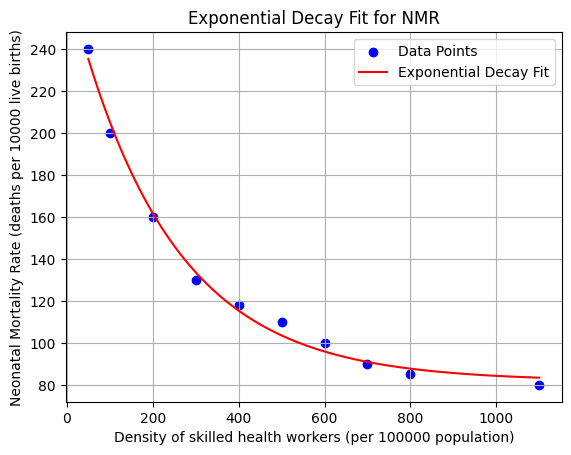

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Given dataset
density = np.array([50, 100, 200, 300, 400, 500, 600, 700, 800, 1100])
NMR = np.array([240, 200, 160, 130, 118, 110, 100, 90, 85, 80])

# Define the exponential decay function
def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

# Fit the curve
params, _ = curve_fit(exp_decay, density, NMR, p0=[250, 0.01, 50])

# Extract fitted parameters
a_fit, b_fit, c_fit = params

# Define the function to predict NMR for a given density
def predict_NMR(density_value):
    return exp_decay(density_value, a_fit, b_fit, c_fit)

# Generate fitted values for visualization
x_fit = np.linspace(min(density), max(density), 100)
y_fit = exp_decay(x_fit, *params)

# Plot the fitted curve
plt.scatter(density, NMR, color='blue', label="Data Points")
plt.plot(x_fit, y_fit, color='red', label="Exponential Decay Fit")
plt.xlabel("Density of skilled health workers (per 100000 population)")
plt.ylabel("Neonatal Mortality Rate (deaths per 10000 live births)")
plt.title("Exponential Decay Fit for NMR")
plt.legend()
plt.grid(True)
plt.show()


In [3]:
import numpy as np

In [7]:
def sample_proportion_with_uncertainty(prop, n, size=1, prior_strength=1):
    """
    Sample proportions from a Beta distribution based on observed data.

    Parameters:
        prop (float): Observed proportion (e.g., 0.26)
        n (int): Sample size used to estimate the proportion
        size (int): Number of random samples to draw
        prior_strength (int or float): Prior weight (default is 1 = uniform prior)

    Returns:
        np.ndarray: Sampled proportion values (array of length `size`)
    """
    # Posterior alpha and beta using Beta(prop*n + prior, (1 - prop)*n + prior)
    alpha = prop * n + prior_strength
    beta = (1 - prop) * n + prior_strength
    return np.random.beta(alpha, beta, size=size)
samples = sample_proportion_with_uncertainty(prop=0.26, n=4419, size=10)
print(np.round(samples, 4))

[0.2651 0.2612 0.2645 0.2563 0.274  0.2555 0.2628 0.2627 0.264  0.2622]


In [9]:
def sample_from_ci(value, lower, upper, n=None, kind='proportion', size=1):
    if kind == 'proportion':
        if n is None:
            # Estimate SE from CI if n is not available
            se = (upper - lower) / (2 * 1.96)
            a, b = (0 - value) / se, (1 - value) / se
            samples = truncnorm.rvs(a, b, loc=value, scale=se, size=size)
        else:
            # Use beta distribution with Jeffreys prior (alpha=1, beta=1)
            alpha = value * n + 1
            beta = (1 - value) * n + 1
            samples = np.random.beta(alpha, beta, size=size)

    elif kind in ['RR', 'OR']:
        # Log-normal sampling: assume log(value) ~ N(log(value), SE)
        mu = np.log(value)
        se = (np.log(upper) - np.log(lower)) / (2 * 1.96)
        samples = np.exp(np.random.normal(loc=mu, scale=se, size=size))

    else:
        raise ValueError("Unsupported 'kind'. Choose from 'proportion', 'RR', or 'OR'.")

    return samples

In [10]:
def get_parameters():
    param = {
        'p_highrisk': sample_from_ci(0.26, 0.247, 0.273, 4419, 'proportion', 1),
    }
    return param

param = get_parameters()
print(param['p_highrisk'])  # e.g., 0.2591

[0.24047657]


In [11]:
print(param['p_highrisk'])  # will print exactly the same value

[0.24047657]


In [24]:
seed = np.random.default_rng(2025).integers(low=0, high=1e6, size=10)

In [1]:
rng = np.random.default_rng(2)
rng

NameError: name 'np' is not defined

In [26]:
for i, seed in enumerate(seeds):
    print(i)
    print(seed)

0
447473
1
994457
2
992582
3
382009
4
953587
5
827148
6
639453
7
837255
8
766262
9
975809


In [30]:
odds_prob(param['or_anc_anemia'], param['p_comp_anemia'], (1 - param['p_ANC_base']))

NameError: name 'odds_prob' is not defined

In [8]:
import psutil
print(f"CPU usage: {psutil.cpu_percent()}%")

CPU usage: 21.3%
